<Figure size 1200x1000 with 0 Axes>

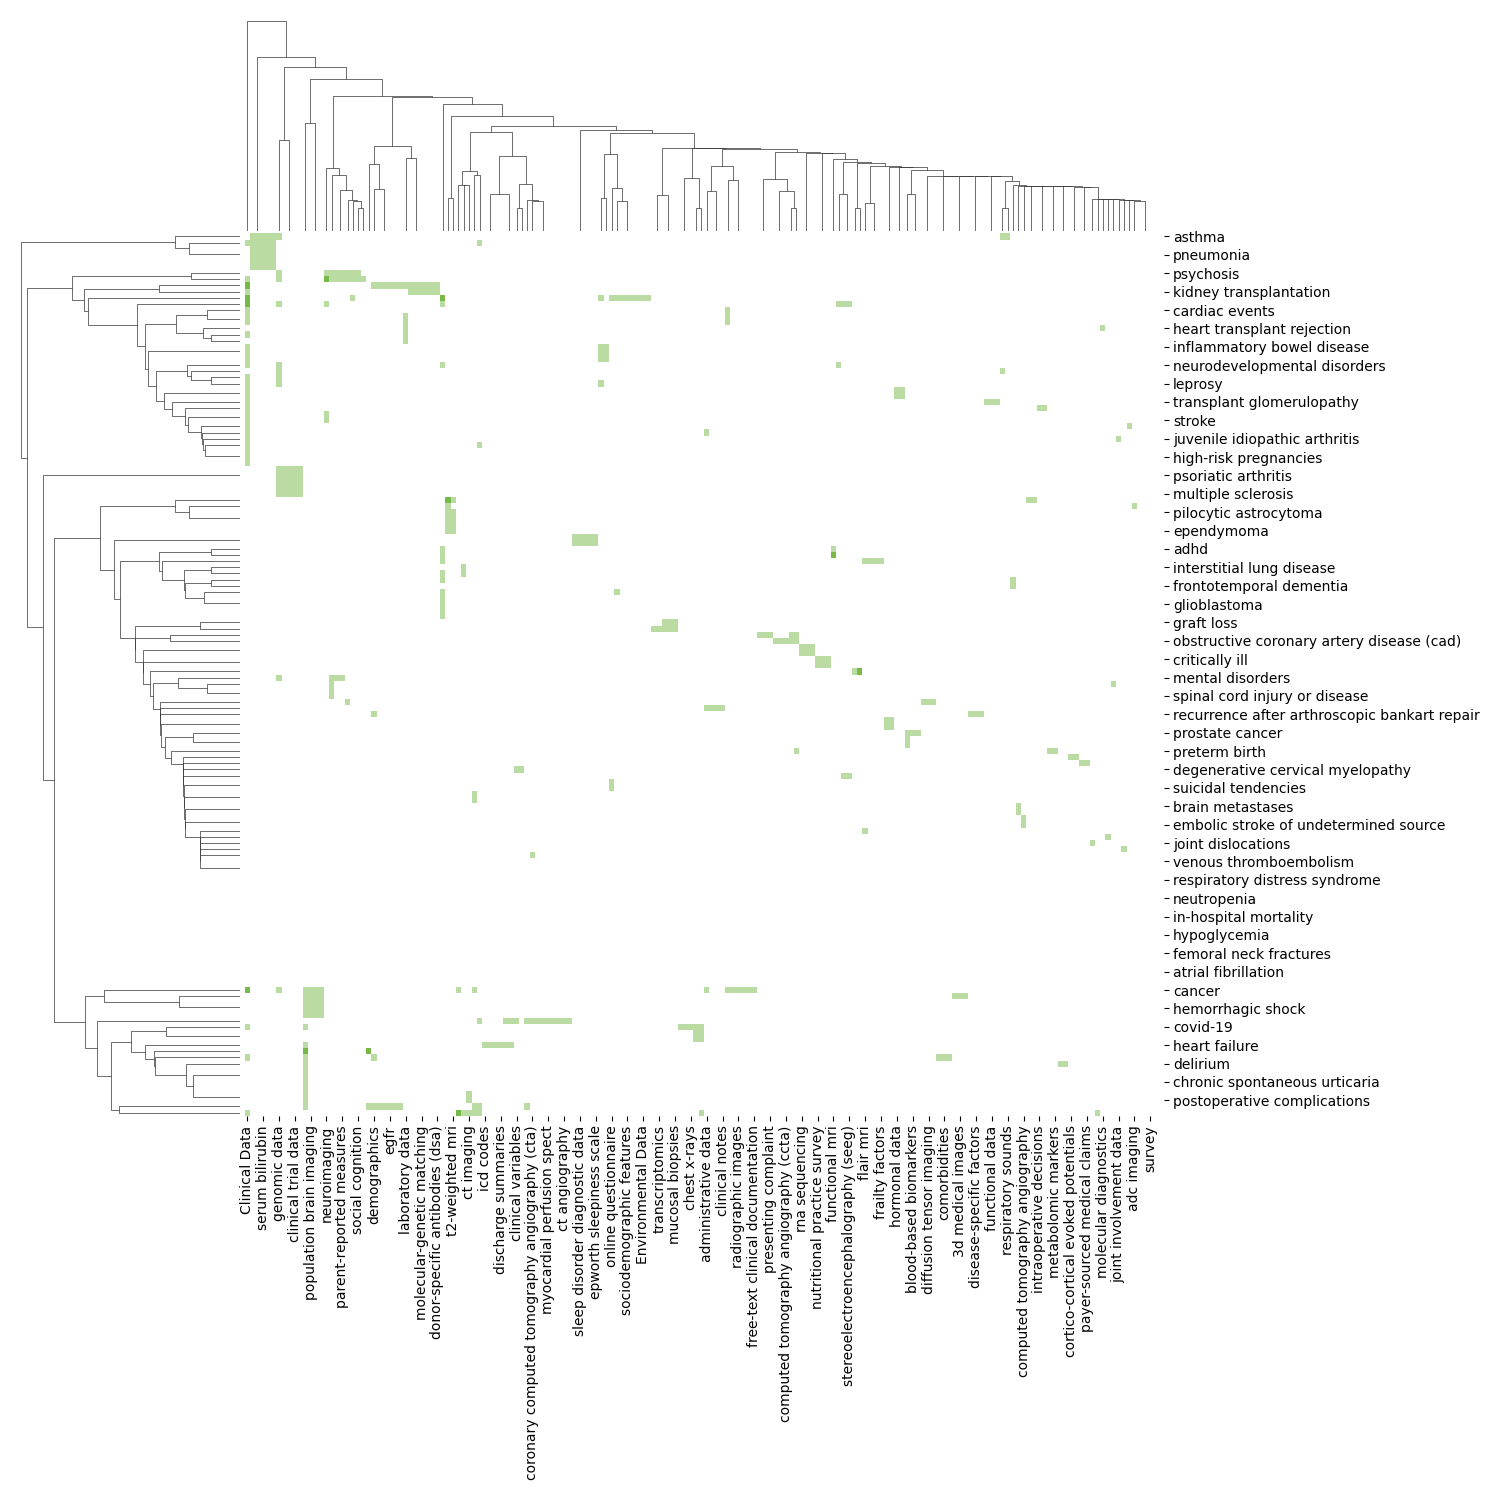

In [3]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import MultiLabelBinarizer
from scipy.cluster.hierarchy import linkage
from matplotlib.colors import LinearSegmentedColormap

# Load your dataset
df = pd.read_csv('final_labeled_diseases_modalities.csv')  # Replace 'your_dataset.csv' with your actual file path

# # Check if diseases and data_modalities are stored as strings that need to be converted
df['normalized_diseases'] = df['normalized_diseases'].apply(lambda x: eval(x) if isinstance(x, str) and x.startswith('[') else [])
df['data_modalities'] = df['data_modalities'].apply(lambda x: eval(x) if isinstance(x, str) and x.startswith('[') else [])


# Define a function to normalize modalities
def normalize_modality_name(modality):
    modality = modality.lower().strip()
    
    # Dictionary for manual normalization of modalities
    normalization_map = {
        "ehr": "electronic health records",
        "electronic medical records": "electronic health records",
        "clinical data": "clinical data",
        "fmri": "functional mri",
        "mri": "magnetic resonance imaging",
        "mpi": "myocardial perfusion imaging",
        "ct": "computed tomography",
        "x-ray": "x-ray",
        "ultrasound": "ultrasound"
    }
    
    return normalization_map.get(modality, modality)

# Apply normalization to the 'data_modalities' column
df['normalized_modalities'] = df['data_modalities'].apply(lambda modalities: [normalize_modality_name(mod) for mod in modalities])

# Define a function to normalize and combine modalities
def combine_modalities(modalities):
    modality_map = {
        'electronic health records': 'EHR',
        'electronic medical records': 'EHR',
        'mri': 'MRI',
        'volumetric mri': 'MRI',
        'fmri': 'fMRI',
        'ct': 'CT',
        'x-ray': 'X-ray',
        'ultrasound images': 'Ultrasound',
        'myocardial perfusion imaging': 'Other Imaging',
        'biopsy imaging': 'Other Imaging',
        'imaging': 'Other Imaging',
        'gene expression': 'Genomic Data',
        'genetic data': 'Genomic Data',
        'genomics': 'Genomic Data',
        'genomic sequencing': 'Genomic Data',
        'clinical data': 'Clinical Data',
        'clinical records': 'Clinical Data',
        'patient demographics': 'Clinical Data',
        'patient characteristics': 'Clinical Data',
        'laboratory-confirmed cases': 'Laboratory Data',
        'lab results': 'Laboratory Data',
        'biomarker data': 'Laboratory Data',
        'biopsies': 'Laboratory Data',
        'laboratory findings': 'Laboratory Data',
        'surveys': 'Survey Data',
        'self-report data': 'Survey Data',
        'self-reported measures': 'Survey Data',
        'qualitative interviews': 'Survey Data',
        'cognitive data': 'Psychological Data',
        'psychopathology': 'Psychological Data',
        'episodic memory': 'Psychological Data',
        'psychological assessments': 'Psychological Data',
        'environmental data': 'Environmental Data',
        'environmental health records': 'Environmental Data',
        'environmental factors': 'Environmental Data'
    }
    
    return [modality_map.get(mod, mod) for mod in modalities]

# Apply normalization and combine modalities
df['combined_modalities'] = df['normalized_modalities'].apply(combine_modalities)

# Initialize MultiLabelBinarizer for diseases and modalities
mlb_diseases = MultiLabelBinarizer()
mlb_modalities = MultiLabelBinarizer()

# Transform the lists of diseases and modalities into binary matrices
disease_matrix = mlb_diseases.fit_transform(df['normalized_diseases'])
combined_modality_matrix = mlb_modalities.fit_transform(df['combined_modalities'])

# Convert to DataFrames for better analysis
disease_df = pd.DataFrame(disease_matrix, columns=mlb_diseases.classes_)
combined_modality_df = pd.DataFrame(combined_modality_matrix, columns=mlb_modalities.classes_)

# Compute the correlation between diseases and combined modalities
combined_correlation_matrix = pd.DataFrame(disease_df.T.dot(combined_modality_df), index=mlb_diseases.classes_, columns=mlb_modalities.classes_)

# Filter out rows and columns that have all zero values to focus on meaningful co-occurrences
filtered_correlation_matrix = combined_correlation_matrix.loc[(combined_correlation_matrix != 0).any(axis=1), (combined_correlation_matrix != 0).any(axis=0)]


# Perform hierarchical clustering on diseases and modalities
combined_disease_linkage = linkage(combined_correlation_matrix, method='ward')
combined_modality_linkage = linkage(combined_correlation_matrix.T, method='ward')

# Create a custom colormap based on the specified color
custom_cmap = LinearSegmentedColormap.from_list("custom_green", ["white", "#76b947"])

# Plot the heatmap with hierarchical clustering
plt.figure(figsize=(12, 10))
sns.clustermap(
    combined_correlation_matrix, 
    row_linkage=combined_disease_linkage, 
    col_linkage=combined_modality_linkage, 
    cmap=custom_cmap, 
    figsize=(15, 15), 
    cbar_pos=None  # Remove the color bar
)

# Show the plot
plt.show()


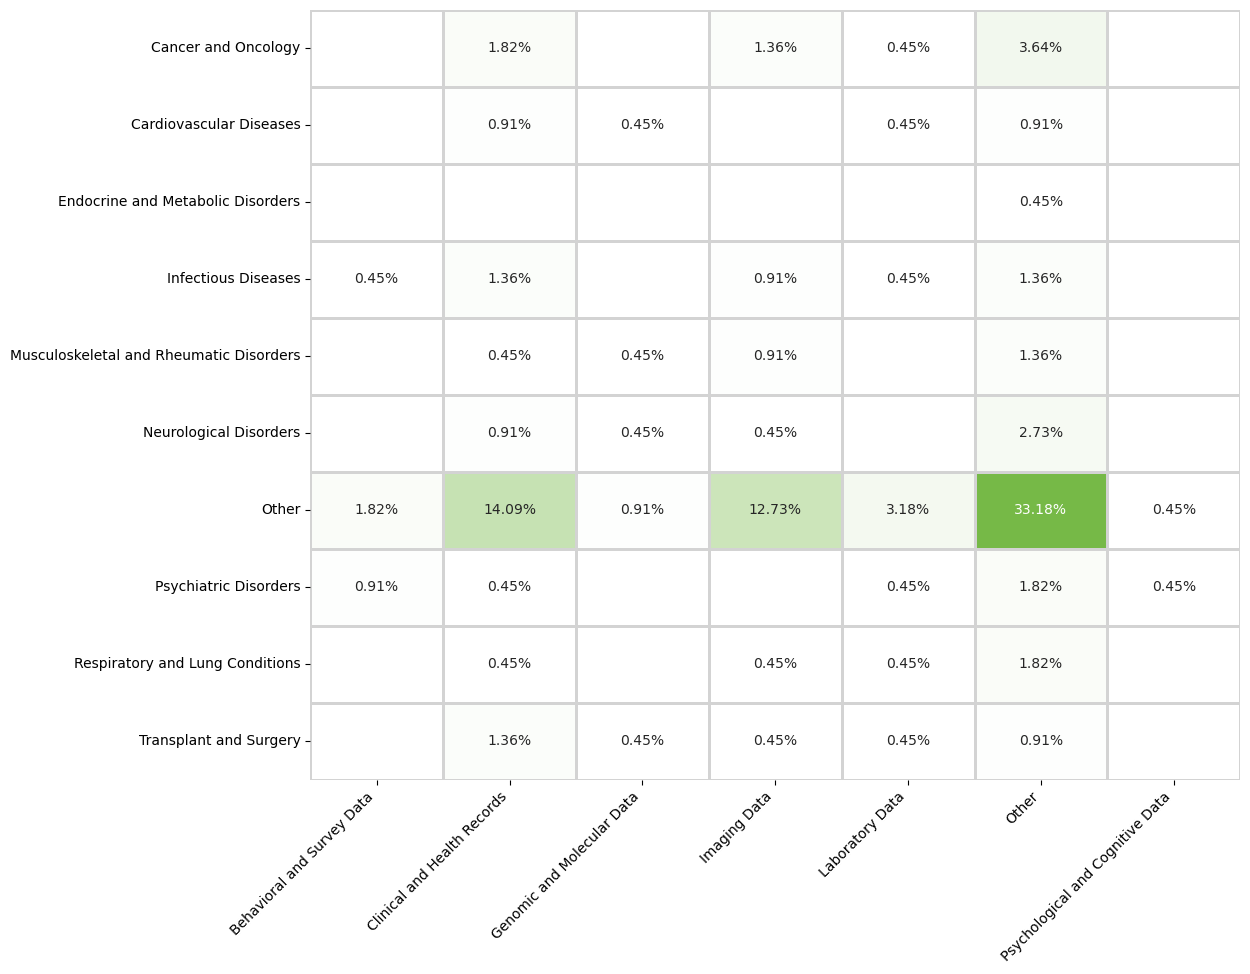

In [4]:
# Re-import necessary libraries and reload the dataset
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import MultiLabelBinarizer
from scipy.cluster.hierarchy import linkage
from matplotlib.colors import LinearSegmentedColormap
import ast

# Load your dataset
file_path = 'final_labeled_diseases_modalities.csv'  # Update this path if necessary
df = pd.read_csv(file_path)

# Check if diseases and data_modalities are stored as strings that need to be converted
df['normalized_diseases'] = df['normalized_diseases'].apply(lambda x: ast.literal_eval(x) if isinstance(x, str) and x.startswith('[') else [])
df['data_modalities'] = df['data_modalities'].apply(lambda x: ast.literal_eval(x) if isinstance(x, str) and x.startswith('[') else [])

# Grouping function for diseases
def group_diseases(disease):
    disease_groups = {
        'Neurological Disorders': ['multiple sclerosis', 'neurodevelopmental disorders', 'epilepsy', 'frontotemporal dementia', 'glioblastoma'],
        'Cardiovascular Diseases': ['coronary artery disease', 'atrial fibrillation', 'stroke', 'heart transplant rejection', 'cardiac events'],
        'Infectious Diseases': ['covid-19', 'pneumonia', 'leprosy', 'viral infections', 'sepsis'],
        'Respiratory and Lung Conditions': ['asthma', 'chronic obstructive pulmonary disease', 'interstitial lung disease', 'respiratory distress syndrome', 'venous thromboembolism'],
        'Cancer and Oncology': ['prostate cancer', 'brain metastases', 'ependymoma', 'hemorrhagic shock', 'cancer'],
        'Transplant and Surgery': ['kidney transplantation', 'graft loss', 'transplant glomerulopathy', 'recurrent disease after surgery', 'postoperative complications'],
        'Endocrine and Metabolic Disorders': ['hypoglycemia', 'metabolic syndrome', 'preterm birth', 'obesity', 'diabetes'],
        'Musculoskeletal and Rheumatic Disorders': ['psoriatic arthritis', 'joint dislocations', 'degenerative cervical myelopathy', 'hip fractures', 'juvenile idiopathic arthritis'],
        'Psychiatric Disorders': ['mental disorders', 'suicidal tendencies', 'psychosis', 'delirium', 'substance abuse'],
        'Other': []  # For diseases that don't fit into the above categories
    }
    
    for group, diseases in disease_groups.items():
        if disease in diseases:
            return group
    return 'Other'

# Apply grouping to diseases
df['grouped_diseases'] = df['normalized_diseases'].apply(lambda diseases: [group_diseases(disease) for disease in diseases])

# Update the grouping function to combine 'Survey and Self-Reported Data' with 'Behavioral Data'
def group_modalities_combined_v2(modality):
    modality_groups = {
        'Imaging Data': ['ct', 'mri', 'ultrasound', 'fmri', 'x-ray', 'computed tomography', 'ct imaging', 
                         'mr imaging', 't1-weighted images', 't2-weighted images', 'spect imaging', 
                         'ct scan', 'ct angiography', 'coronary computed tomography angiography (cta)', 
                         'computed tomography angiography', 'radiographs', 'chest x-rays', 
                         'mri imaging', 'diffusion mri', 'diffusion tensor imaging', 'flair mri',
                         'radiographic images', 'pet images', 'cine mr', 'echocardiographic images',
                         'spect myocardial perfusion imaging', 'myocardial perfusion imaging (mpi)',
                         'myocardial perfusion spect', 'biopsy imaging', 'specialized imaging techniques', 
                         'transcranial magnetic stimulation', 'adc imaging'],  # Combined both Imaging groups here
        'Genomic and Molecular Data': ['genomic sequencing', 'gene expression', 'molecular markers', 
                                       'biomarker data', 'proteomic data', 'transcriptomic data', 
                                       'molecular diagnostics', 'gene expression microarrays'],
        'Clinical and Health Records': ['electronic health records', 'clinical data', 'medical records', 
                                        'structured clinical data', 'free-text clinical documentation',
                                        'ehr', 'administrative claims', 'administrative data'],
        'Psychological and Cognitive Data': ['psychological assessments', 'cognitive measures', 'episodic memory', 
                                             'psychopathology', 'cognitive assessments', 'personality clusters'],
        'Behavioral and Survey Data': ['surveys', 'self-reported measures', 'qualitative interviews', 'survey data',
                                       'questionnaire data', 'online questionnaire', 'parent-reported measures',
                                       'behavioral observations', 'patient-reported outcomes'],
        'Laboratory Data': ['lab results', 'biopsies', 'laboratory-confirmed cases', 'laboratory data', 
                            'serum creatinine', 'serum bilirubin', 'plasma glycosaminoglycan profiles',
                            'laboratory tests', 'transbronchial biopsies', 'mucosal biopsies'],
        'Environmental Data': ['environmental health records', 'environmental factors'],
        'Other': []  # For modalities that don't fit into the above categories
    }
    
    modality = modality.lower().strip()
    
    for group, modalities in modality_groups.items():
        if modality in modalities:
            return group
    return 'Other'

# Apply the updated grouping function to modalities
df['grouped_modalities'] = df['data_modalities'].apply(lambda modalities: [group_modalities_combined_v2(modality) for modality in modalities])

# Initialize MultiLabelBinarizer for grouped diseases and modalities
mlb_diseases = MultiLabelBinarizer()
mlb_modalities = MultiLabelBinarizer()

# Transform the lists of grouped diseases and modalities into binary matrices
disease_matrix = mlb_diseases.fit_transform(df['grouped_diseases'])
modality_matrix = mlb_modalities.fit_transform(df['grouped_modalities'])

# Convert to DataFrames for better analysis
disease_df = pd.DataFrame(disease_matrix, columns=mlb_diseases.classes_)
modality_df = pd.DataFrame(modality_matrix, columns=mlb_modalities.classes_)

# Compute the correlation between grouped diseases and grouped modalities
correlation_matrix = pd.DataFrame(disease_df.T.dot(modality_df), index=mlb_diseases.classes_, columns=mlb_modalities.classes_)

# Filter out rows and columns that have all zero values to focus on meaningful co-occurrences
filtered_correlation_matrix_v2 = correlation_matrix.loc[(correlation_matrix != 0).any(axis=1), (correlation_matrix != 0).any(axis=0)]

# Recalculate total for percentage normalization
total_sum_combined_v2 = filtered_correlation_matrix_v2.values.sum()

# Create a custom colormap based on the specified color
custom_cmap = LinearSegmentedColormap.from_list("custom_green", ["white", "#76b947"])

# Plot the heatmap with the combined survey and behavioral data
plt.figure(figsize=(12, 10))
sns.heatmap(
    filtered_correlation_matrix_v2 / total_sum_combined_v2,  # Normalize the data
    cmap=custom_cmap, 
    annot=True, 
    fmt=".2%",  # Show percentages
    cbar=False,  # Do not display the color bar
    linewidths=1,  # Add lines between cells
    linecolor='lightgrey',  # Set line color to light grey
    mask=(filtered_correlation_matrix_v2 == 0),  # Mask zero values
    annot_kws={"ha": "center", "va": "center"}  # Center align text
)

# Rotate x-axis labels 45 degrees and leave y-axis labels unrotated
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0, ha='right')

# Show the heatmap with the updated groupings
plt.show()


In [5]:
import pandas as pd
import ast

# Load the dataset
file_path = 'dataset_150.csv'  # Replace with the path to your dataset
df = pd.read_csv(file_path)

# Refined disease categories
refined_disease_categories_final = {
    'Neurological Disorders': ['epilepsy', 'multiple sclerosis', 'dementia', 'alzheimer', 'parkinson', 'autism', 'amyotrophic lateral sclerosis', 'progressive supranuclear palsy', 'narcolepsy', 'delirium', 'obsessive-compulsive disorder', 'mental illness'],
    'Cardiovascular and Vascular Diseases': ['coronary artery disease', 'myocardial infarction', 'heart failure', 'stroke', 'peripheral artery disease', 'hypertension', 'atherosclerosis', 'acute aortic dissection', 'abdominal aortic aneurysm', 'atrial fibrillation', 'cardiometabolic disease', 'heart disease', 'in-hospital cardiac arrest'],
    'Respiratory and Lung Conditions': ['pneumonia', 'copd', 'asthma', 'lung cancer', 'interstitial lung disease', 'acute respiratory distress syndrome', 'covid-19', 'pulmonary embolism', 'pulmonary emphysema', 'venous thromboembolism', 'lung conditions', 'chronic obstructive pulmonary disease', 'lung sliding artifact'],
    'Cancer and Oncology': ['prostate cancer', 'breast cancer', 'non-small cell lung cancer', 'glioblastoma', 'head and neck cancer', 'melanoma', 'leukemia', 'ependymoma', 'oral cancer', 'cervical cancer', 'colorectal cancer', 'brain metastasis', 'medulloblastoma', 'intrahepatic cholangiocarcinoma', 'cancer'],
    'Endocrine and Metabolic Disorders': ['diabetes', 'hypoglycemia', 'hyperkalemia', 'obesity', 'metabolic syndrome'],
    'Musculoskeletal and Rheumatic Disorders': ['arthritis', 'psoriatic arthritis', 'juvenile idiopathic arthritis', 'degenerative cervical myelopathy', 'axial spondyloarthritis', 'osteoporosis', 'joint dislocations', 'femoral neck fractures'],
    'Psychiatric and Mental Health Disorders': ['depression', 'anxiety', 'psychosis', 'mental health', 'schizophrenia', 'autism', 'adhd', 'bipolar disorder', 'major depressive disorder', 'major depressive disorder (mdd)'],
    'Infectious Diseases': ['covid-19', 'leprosy', 'dengue', 'sepsis', 'viral infections', 'pneumonia', 'pertussis', 'hepatitis', 'tuberculosis', 'invasive pneumococcal disease'],
    'Transplant and Surgery': ['kidney transplantation', 'graft loss', 'lung transplant rejection', 'postoperative complications', 'heart transplant rejection', 'transplant glomerulopathy'],
    'Kidney and Renal Diseases': ['chronic kidney disease', 'end-stage kidney disease', 'renal cancer'],
    'Neonatal and Pregnancy-Related Conditions': ['neonatal death', 'preterm birth', 'severe neonatal morbidity', 'high-risk pregnancies'],
    'Rare Diseases': ['rare genetic diseases', 'pediatric low-grade neuroepithelial tumor', 'pediatric posterior fossa tumors', 'pnsts', 'transitional mesothelioma'],
    'Surgical and Trauma Conditions': ['aortic arch surgery', 'recurrence after arthroscopic bankart repair', 'traumatic anterior shoulder dislocations', 'surgical performance', 'traumatic spinal cord injury'],
    'Reproductive Health': ['infertility', 'varicocele'],
    'Critical Care': ['critically ill', 'mechanical ventilation', 'acute care assessment'],
    'Other': []
}

# Safely convert stringified lists to actual lists
def safe_eval(disease_str):
    try:
        return ast.literal_eval(disease_str) if isinstance(disease_str, str) else []
    except (ValueError, SyntaxError):
        return []

# Function to categorize diseases based on the refined categories
def refined_categorize_disease_final(disease_list):
    general_category = 'Other'
    for category, diseases in refined_disease_categories_final.items():
        for disease in diseases:
            if any(disease.lower() in d.lower() for d in disease_list):
                return category
    return general_category

# Apply the conversion and categorization
df['disease_list'] = df['diseases'].apply(safe_eval)
df['refined_general_category_final'] = df['disease_list'].apply(refined_categorize_disease_final)

# Get the final distribution of categories
final_category_distribution = df['refined_general_category_final'].value_counts()

# Save the updated dataset to a CSV file
output_refined_file_path = 'dataset_150.csv'  # Replace with your desired path
df.to_csv(output_refined_file_path, index=False)

# Display the final category distribution and file save confirmation
print(final_category_distribution)
print(f"Updated dataset saved to {output_refined_file_path}")


refined_general_category_final
Respiratory and Lung Conditions              28
Cardiovascular and Vascular Diseases         25
Neurological Disorders                       23
Cancer and Oncology                          19
Psychiatric and Mental Health Disorders      15
Other                                        13
Transplant and Surgery                        6
Infectious Diseases                           5
Kidney and Renal Diseases                     5
Musculoskeletal and Rheumatic Disorders       4
Rare Diseases                                 4
Surgical and Trauma Conditions                4
Neonatal and Pregnancy-Related Conditions     3
Critical Care                                 2
Reproductive Health                           2
Endocrine and Metabolic Disorders             2
Name: count, dtype: int64
Updated dataset saved to dataset_150.csv


In [49]:
import pandas as pd
import ast
import nltk
from nltk.stem import PorterStemmer
from nltk.tokenize import word_tokenize

# Download punkt tokenizer (run once)
nltk.download('punkt')

# Load the dataset
# file_path = 'dataset_150.csv'  # Replace with the path to your dataset
# df = pd.read_csv(file_path)

# Initialize the stemmer
stemmer = PorterStemmer()

# Function to stem the words in the 'modalities' column
def stem_modalities(modality_str):
    try:
        modality_list = ast.literal_eval(modality_str) if isinstance(modality_str, str) else []
        stemmed_modalities = []
        for modality in modality_list:
            words = word_tokenize(modality)
            stemmed_words = [stemmer.stem(word) for word in words]
            stemmed_modalities.append(' '.join(stemmed_words))
        return stemmed_modalities
    except (ValueError, SyntaxError):
        return []

# Apply stemming to the 'modalities' column
df['stemmed_modalities'] = df['modalities'].apply(stem_modalities)

# Define the modality groups

modality_groups = {
    'Imaging Data': [
        'ct', 'mri', 'ultrasound', 'fmri', 'x-ray', 'computed tomography', 'ct imaging', 'radiographs',
        'pet images', 'cine mr', 'diffusion tensor imaging (dti)', 'flair mri', 'echocardiographic images',
        'chest x-ray (cxr)', 'coronary computed tomography angiography (cta)', 'diffusion mri', 'lung ultrasound',
        'digit imag', 'neuroimaging', 'structur mri', 'cardiac mri', 'mri imag', 'frontal imag', 'facial photograph',
        'biopsy imaging', 'transcranial magnetic stimulation', 'adc imaging', 'myocardial perfusion spect', 
        'myocardial perfusion imaging (mpi)'
    ],
    'Genomic and Molecular Data': [
        'genomic sequencing', 'gene expression', 'molecular markers', 'biomarker data', 'proteomic data',
        'transcriptomic data', 'molecular diagnostics', 'genet data', 'genet inform', 'whole-genom sequenc (wg)',
        'rna sequenc', 'blood-bas biomark', 'molecular-genetic matching', 'immunolog marker', 'immunolog data',
        'molecular diagnostics', 'dna', 'sequencing', 'chromosomal markers'
    ],
    'Clinical and Health Records': [
        'electronic health records', 'clinical data', 'medical records', 'ehr', 'administrative claims',
        'clinical trials', 'administrative data', 'clinical outcomes', 'emr', 'clinical notes', 'consultation notes',
        'physiolog monitor data', 'hospital admissions', 'discharg summari', 'electron medic record',
        'electron health record (ehr)', 'clinic record', 'clinic note', 'administr data', 'reason for admiss'
    ],
    'Laboratory Data': [
        'lab results', 'biopsies', 'serum creatinine', 'serum bilirubin', 'plasma glycosaminoglycan profiles',
        'laboratory tests', 'transbronchial biopsies', 'mucosal biopsies', 'laboratory-confirmed cases', 'laboratori data'
    ],
    'Digital Health & Wearable Devices': [
        'wearabl devic', 'digit messag', 'teletherapi', 'video teletherapi', 'digital data', 'keystrok metric',
        'virtual realiti', 'object pap usag data', 'digit patholog'
    ],
    'Neurophysiological Data': [
        'eeg', 'seeg', 'ieeg', 'local-field potenti (lfp)', 'ccep', 'resting-st magnetoencephalographi (meg)',
        'cortico-cort evok potenti', 'neurocognit assess', 'stereoelectroencephalographi (seeg)'
    ],
    'Self-reported & Survey Data': [
        'self-reported measures', 'surveys', 'questionnaire data', 'self-report data', 'social/behavioral assessments',
        'nutrit practic survey', 'patient-report outcomes', 'self-report questionnair', 'parent-report measur',
        'semi-structur qualit interview'
    ],
    'Clinical Studies & Trials': [
        'clinical trials', 'study data', 'longitudinal data', 'demographic/clinical data', 'clinical covariates',
        'baselin injuri characterist', 'patient-specif factor', 'clinic biomark data', 'type data'
    ],
    'Other': []  # For modalities that don't fit into the above categories
}
# Function to categorize modalities
def categorize_modality(modality_list):
    for modality in modality_list:
        for category, modalities in modality_groups.items():
            if any(modality.lower() in m.lower() for m in modalities):
                return category
    return 'Other'

# Apply categorization to the stemmed modalities
df['modality_category'] = df['stemmed_modalities'].apply(categorize_modality)

# Save the updated dataset to a CSV file
output_refined_file_path = 'dataset_150_result.csv'  # Replace with your desired path
df.to_csv(output_refined_file_path, index=False)

df


[nltk_data] Downloading package punkt to /Users/yumcoder/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


,pid,diseases,modalities,disease_list,refined_general_category_final,stemmed_modalities,modality_category
0,32943286,"[""lung transplant rejection"", ""graft loss""]","[""transbronchial biopsies"", ""mucosal biopsies""...","[lung transplant rejection, graft loss]",Transplant and Surgery,"[transbronchi biopsi, mucos biopsi, gene expre...",Other
1,29886760,"[""Severe Neonatal Morbidity"", ""neonatal death""]","[""Maternal age"", ""reason for admission"", ""Gest...","[Severe Neonatal Morbidity, neonatal death]",Neonatal and Pregnancy-Related Conditions,"[matern age, reason for admiss, gestat age, op...",Clinical and Health Records
2,30262516,"[""Cardiovascular"",""obstructive coronary artery...","[""SPECT Myocardial Perfusion Imaging"", ""MPI""]","[Cardiovascular, obstructive coronary artery d...",Cardiovascular and Vascular Diseases,"[spect myocardi perfus imag, mpi]",Imaging Data
3,36332954,"[""anxiety disorders"",""mental health""]","[""Self-report questionnaires"", ""Semi-structure...","[anxiety disorders, mental health]",Psychiatric and Mental Health Disorders,"[self-report questionnair, semi-structur quali...",Self-reported & Survey Data
4,30807586,"[""Juvenile Idiopathic Arthritis""]","[""Clinical data"", ""Joint involvement data"", ""l...",[Juvenile Idiopathic Arthritis],Musculoskeletal and Rheumatic Disorders,"[clinic data, joint involv data, laboratori pa...",Genomic and Molecular Data
...,...,...,...,...,...,...,...
155,38772191,"[""interstitial lung disease""]","[""computed tomography"",""CT""]",[interstitial lung disease],Respiratory and Lung Conditions,"[comput tomographi, ct]",Imaging Data
156,38807510,"[""chronic kidney disease""]","[""Clinical data"",""Laboratory data""]",[chronic kidney disease],Kidney and Renal Diseases,"[clinic data, laboratori data]",Laboratory Data
157,38902526,"[""Prostate Cancer"", ""Clinically Significant Pr...","[""Blood-based Biomarkers"", ""Clinical Biomarker...","[Prostate Cancer, Clinically Significant Prost...",Cancer and Oncology,"[blood-bas biomark, clinic biomark data]",Genomic and Molecular Data
158,38906883,"[""major depressive disorder""]","[""clinical data"", ""sociodemographic data"", ""Tr...",[major depressive disorder],Psychiatric and Mental Health Disorders,"[clinic data, sociodemograph data, treatment r...",Other


In [15]:
# Get the distribution of modalities across the defined categories
modality_distribution = df['modality_category'].value_counts()

# Display the distribution of modalities
modality_distribution

modality_category
Clinical and Health Records          62
Imaging Data                         62
Neurophysiological Data               8
Self-reported & Survey Data           7
Genomic and Molecular Data            7
Digital Health & Wearable Devices     5
Laboratory Data                       4
Other                                 3
Environmental and Social Data         2
Name: count, dtype: int64

In [16]:
# Filter out modalities that are still categorized as "Other"
other_modalities = df[df['modality_category'] == 'Other']['stemmed_modalities']

# Get a set of unique modalities still categorized as "Other"
unique_other_modalities = set(modality for modality_list in other_modalities for modality in modality_list)

# Convert the set of unique modalities into a DataFrame
unique_other_modalities_df = pd.DataFrame(unique_other_modalities, columns=['Modality'])

# Save the unique "Other" modalities to a CSV file
unique_other_modalities_df.to_csv(output_refined_file_path, index=False)

print(f"Unique 'Other' modalities saved to {output_refined_file_path}")

Unique 'Other' modalities saved to dataset_150_result.csv


In [17]:
import pandas as pd
import ast
import nltk
from nltk.stem import PorterStemmer
from nltk.tokenize import word_tokenize

# Download punkt tokenizer (run once)
nltk.download('punkt')

# Load the dataset
# file_path = 'dataset_150.csv'  # Replace with the path to your dataset
# df = pd.read_csv(file_path)

# Initialize the stemmer
stemmer = PorterStemmer()

# Function to stem the words in the 'modalities' column
def stem_modalities(modality_str):
    try:
        modality_list = ast.literal_eval(modality_str) if isinstance(modality_str, str) else []
        stemmed_modalities = []
        for modality in modality_list:
            words = word_tokenize(modality)
            stemmed_words = [stemmer.stem(word) for word in words]
            stemmed_modalities.append(' '.join(stemmed_words))
        return stemmed_modalities
    except (ValueError, SyntaxError):
        return []

# Apply stemming to the 'modalities' column
df['stemmed_modalities'] = df['modalities'].apply(stem_modalities)

# Refined modality groups based on manual review
modality_groups_refined_manual = {
    'Imaging Data': [
        'diffus tensor imag ( dti )', 'chest x-ray ( cxr )', 'frontal imag ( ap/pa )',
        'ct', 'mri', 'ultrasound', 'fmri', 'x-ray', 'computed tomography', 'ct imaging', 'radiographs',
        'pet images', 'cine mr', 'diffusion tensor imaging (dti)', 'flair mri', 'echocardiographic images',
        'chest x-ray (cxr)', 'coronary computed tomography angiography (cta)', 'diffusion mri', 'lung ultrasound',
        'digit imag', 'neuroimaging', 'structur mri', 'cardiac mri', 'mri imag', 'frontal imag', 'facial photograph',
        'biopsy imaging', 'transcranial magnetic stimulation', 'adc imaging', 'myocardial perfusion spect', 
        'myocardial perfusion imaging (mpi)', 'ct angiographi', 'ct scan', 'quantit coronari plaqu analysi', 
        'radiom', 'diffus mri', 'echocardiograph imag', 'myocardi perfus spect', 'ultrasound imag'
    ],
    'Genomic and Molecular Data': [
        'genomic sequencing', 'gene expression', 'molecular markers', 'biomarker data', 'proteomic data',
        'transcriptomic data', 'molecular diagnostics', 'genet data', 'genet inform', 'whole-genom sequenc (wg)',
        'rna sequenc', 'blood-bas biomark', 'molecular-genetic matching', 'immunolog marker', 'immunolog data',
        'molecular diagnostics', 'dna', 'sequencing', 'chromosomal markers', 'gene express microarray', 'omicron',
        'genom data', 'whole-genom sequenc',
        'whole-genom sequenc ( wg )',
    ],
    'Clinical and Health Records': [
        'electronic health records', 'clinical data', 'medical records', 'ehr', 'administrative claims',
        'clinical trials', 'administrative data', 'clinical outcomes', 'emr', 'clinical notes', 'consultation notes',
        'physiolog monitor data', 'hospital admissions', 'discharg summari', 'electron medic record',
        'electron health record (ehr)', 'clinic record', 'clinic note', 'administr data', 'reason for admiss',
        'neurolog statu', 'demograph data', 'sociodemograph data', 'clinic variabl', 'electron medic record data',
        'clinic mental health data', 'patient demograph', 'pre-op demographic/clin variabl', 'sex', 'patient characterist',
        'parent medic histori', 'clinic data',
        'consult note', 'emr data','electron medic record ( emr )',
        'electron health record ( ehr )',
         'frailti factor', 'age at treatment', 'mortal and stroke risk factor',
         'clinical trials', 'study data', 'longitudinal data', 'demographic/clinical data', 'clinical covariates',
        'baselin injuri characterist', 'patient-specif factor', 'clinic biomark data', 'type data'
    ],
    'Laboratory Data': [
        'lab results', 'biopsies', 'serum creatinine', 'serum bilirubin', 'plasma glycosaminoglycan profiles',
        'laboratory tests', 'transbronchial biopsies', 'mucosal biopsies', 'laboratory-confirmed cases', 'laboratori data',
        'transbronchi biopsi', 'blood sampl', 'tumour grade', 'lymphovascular invas', 'histolog tumour type',
        'patholog data'
    ],
    'Digital Health & Wearable Devices': [
        'wearabl devic', 'digit messag', 'teletherapi', 'video teletherapi', 'digital data', 'keystrok metric',
        'virtual realiti', 'object pap usag data', 'digit patholog'
    ],
    'Neurophysiological Data': [
        'eeg', 'seeg', 'ieeg', 'local-field potenti (lfp)', 'ccep', 'resting-st magnetoencephalographi (meg)',
        'cortico-cort evok potenti', 'neurocognit assess', 'stereoelectroencephalographi (seeg)', 'ecg',
        'electrocardiogram', 'speech', 'neurolog statu', 'epworth sleepi scale', 'sleep paralysi', 'narcolepsi symptom',
        'sleep disord diagnost data',
        'resting-st magnetoencephalographi (meg)', 'orthogon voltag gradient (ovg)', 'photoplethysmographi (ppg)',
        'orthogon voltag gradient ( ovg )',
        'photoplethysmographi ( ppg )',
        'orthogon voltag gradient ( ovg )',
        'respiratori sound', 'audio'
    ],
    'Self-reported & Survey Data': [
        'self-reported measures', 'surveys', 'questionnaire data', 'self-report data', 'social/behavioral assessments',
        'nutrit practic survey', 'patient-report outcomes', 'self-report questionnair', 'parent-report measur',
        'semi-structur qualit interview', 'belief and attitud',
        'questionnair data'
    ],
    'Environmental and Social Data': [
        'environment data', 'pandemic-specif factor', 'social interact', 'robot intervent',
        'social interact , robot intervent', 'psychopatholog', 'person cluster',
        'population-bas data',
    ],
    
    'Other': []  # For modalities that don't fit into the above categories
}

# Function to categorize modalities
def categorize_modality_refined(modality_list):
    """
    Categorize modalities based on refined modality groups.
    """
    for modality in modality_list:
        for category, modalities in modality_groups_refined_manual.items():
            if any(modality.lower() in m.lower() for m in modalities):
                return category
    return 'Other'

# Apply categorization to the stemmed modalities
df['modality_category'] = df['stemmed_modalities'].apply(categorize_modality_refined)

# Save the updated dataset to a CSV file
output_refined_file_path = 'dataset_150_result.csv'  # Replace with your desired path
df.to_csv(output_refined_file_path, index=False)

# Get the distribution of modalities across the defined categories
modality_distribution = df['modality_category'].value_counts()

# Display the distribution of modalities
print(modality_distribution)


modality_category
Clinical and Health Records          62
Imaging Data                         62
Neurophysiological Data               8
Self-reported & Survey Data           7
Genomic and Molecular Data            7
Digital Health & Wearable Devices     5
Laboratory Data                       4
Other                                 3
Environmental and Social Data         2
Name: count, dtype: int64


[nltk_data] Downloading package punkt to /Users/yumcoder/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


In [18]:
# Convert the list of modalities to a flat structure to avoid the error and display a sample for review
flat_other_modalities_final = [item for sublist in df[df['modality_category'] == 'Other']['stemmed_modalities'] for item in sublist]

# Display the remaining unique entries in the 'Other' category
unique_other_modalities_final = pd.Series(flat_other_modalities_final).unique()
unique_other_modalities_final[:20]

array([], dtype=object)

In [9]:
df.to_csv('./dataset_150_result.csv')
df

,pid,diseases,modalities,disease_list,refined_general_category_final,stemmed_modalities,modality_category
0,32943286,"[""lung transplant rejection"", ""graft loss""]","[""transbronchial biopsies"", ""mucosal biopsies""...","[lung transplant rejection, graft loss]",Transplant and Surgery,"[transbronchi biopsi, mucos biopsi, gene expre...",Laboratory Data
1,29886760,"[""Severe Neonatal Morbidity"", ""neonatal death""]","[""Maternal age"", ""reason for admission"", ""Gest...","[Severe Neonatal Morbidity, neonatal death]",Neonatal and Pregnancy-Related Conditions,"[matern age, reason for admiss, gestat age, op...",Clinical and Health Records
2,30262516,"[""Cardiovascular"",""obstructive coronary artery...","[""SPECT Myocardial Perfusion Imaging"", ""MPI""]","[Cardiovascular, obstructive coronary artery d...",Cardiovascular and Vascular Diseases,"[spect myocardi perfus imag, mpi]",Imaging Data
3,36332954,"[""anxiety disorders"",""mental health""]","[""Self-report questionnaires"", ""Semi-structure...","[anxiety disorders, mental health]",Psychiatric and Mental Health Disorders,"[self-report questionnair, semi-structur quali...",Self-reported & Survey Data
4,30807586,"[""Juvenile Idiopathic Arthritis""]","[""Clinical data"", ""Joint involvement data"", ""l...",[Juvenile Idiopathic Arthritis],Musculoskeletal and Rheumatic Disorders,"[clinic data, joint involv data, laboratori pa...",Clinical and Health Records
...,...,...,...,...,...,...,...
155,38772191,"[""interstitial lung disease""]","[""computed tomography"",""CT""]",[interstitial lung disease],Respiratory and Lung Conditions,"[comput tomographi, ct]",Imaging Data
156,38807510,"[""chronic kidney disease""]","[""Clinical data"",""Laboratory data""]",[chronic kidney disease],Kidney and Renal Diseases,"[clinic data, laboratori data]",Clinical and Health Records
157,38902526,"[""Prostate Cancer"", ""Clinically Significant Pr...","[""Blood-based Biomarkers"", ""Clinical Biomarker...","[Prostate Cancer, Clinically Significant Prost...",Cancer and Oncology,"[blood-bas biomark, clinic biomark data]",Genomic and Molecular Data
158,38906883,"[""major depressive disorder""]","[""clinical data"", ""sociodemographic data"", ""Tr...",[major depressive disorder],Psychiatric and Mental Health Disorders,"[clinic data, sociodemograph data, treatment r...",Clinical and Health Records


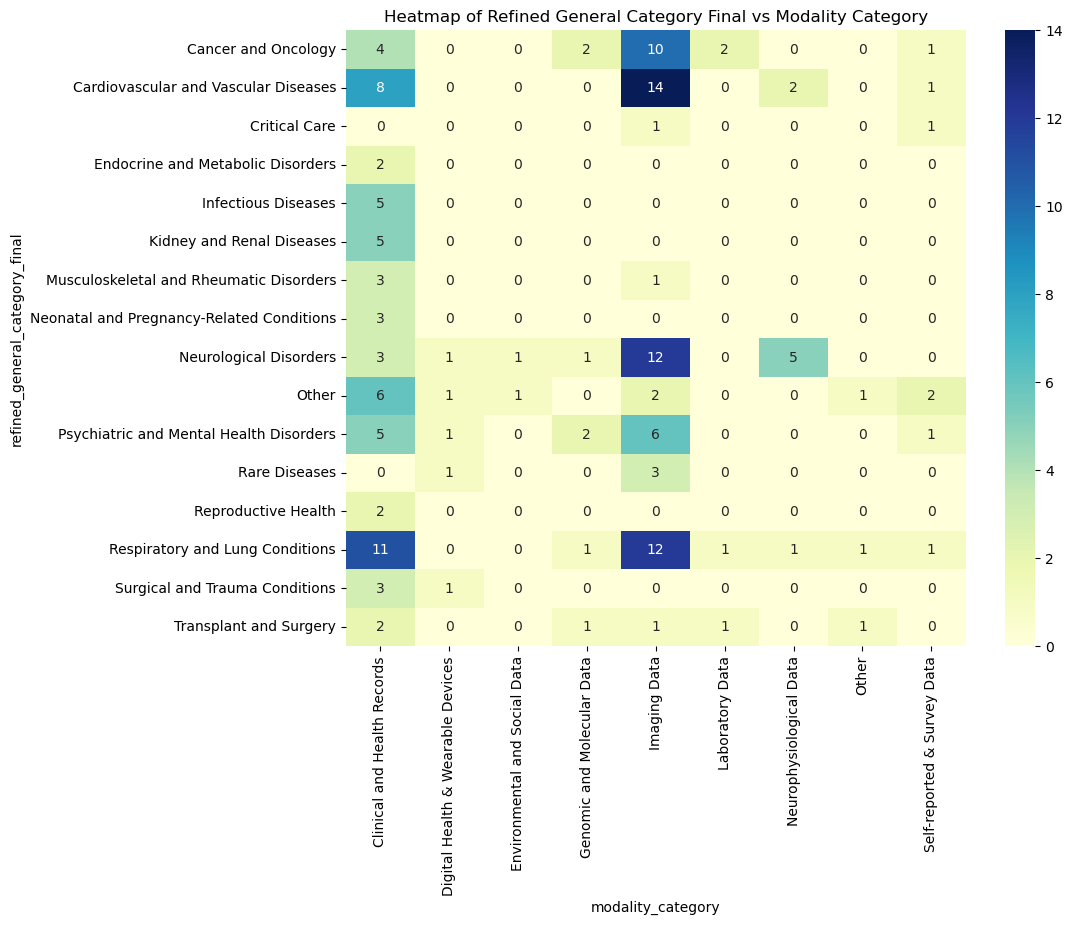

In [19]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Prepare data for the heatmap, using 'refined_general_category_final' and 'modality_category'
heatmap_data = pd.crosstab(df['refined_general_category_final'], df['modality_category'])

# Generate heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(heatmap_data, annot=True, fmt="d", cmap="YlGnBu")

# Display the plot
plt.title("Heatmap of Refined General Category Final vs Modality Category")
plt.show()


/var/folders/gx/4hmfp0zd12bblv6znjwbmv600000gn/T/ipykernel_66782/2474662680.py:3: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  sns.heatmap(heatmap_data, annot=heatmap_data.applymap(lambda v: '' if v == 0 else v), cmap="BuGn", fmt='', cbar_kws={'label': 'Count'}, linewidths=0, linecolor='grey')


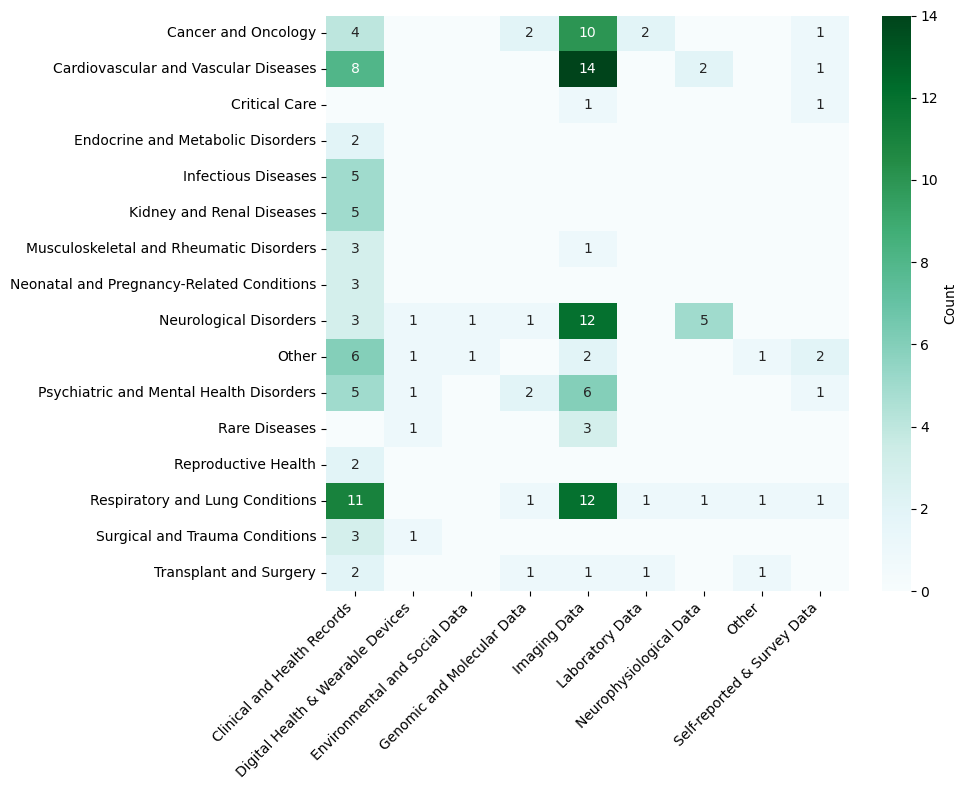

In [20]:
# Plot the heatmap with zero values shown but without the labels for zero
plt.figure(figsize=(10, 8))
sns.heatmap(heatmap_data, annot=heatmap_data.applymap(lambda v: '' if v == 0 else v), cmap="BuGn", fmt='', cbar_kws={'label': 'Count'}, linewidths=0, linecolor='grey')

plt.title('')
plt.xlabel('')
plt.ylabel('')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()

# Show the plot
plt.show()
